# OPA Sale Price EDA and Feature Analysis

## I. Executive Summary

This notebook explores OPA property data to identify which features are most useful for predicting `sale_price`, the actual transaction price of a property. The analysis focuses on exploratory data analysis, feature usefulness, and the preprocessing steps needed for future model training.

The results suggest that property value is most strongly associated with size, assessment-related variables, and quality indicators. In particular, `taxable_building`, `total_livable_area`, and `quality_grade` appear to be the most useful predictors. By contrast, `bedrooms`, `bathrooms`, and `age` appear to be weaker standalone predictors.

The notebook also accounts for several important data issues. Very low sale prices were excluded because they are unlikely to reflect real market transactions. Likely bundle sales were identified using repeated combinations of `sale_date` and `target_sale_price`, and a filtered modeling dataset was created excluding those records. In addition, `sale_date` was examined as an important contextual factor because it appears to capture broader market timing effects. However, it is treated here as a market context variable rather than a required core feature for the main interpretable baseline model.

## II. Data Source and Scope

### 2.1 Dataset Description

The data used in this notebook comes from the OPA property dataset extracted from BigQuery and exported locally for analysis. The CSV file is used only for exploration and is not committed to the repository.

### 2.2 Target Variable

The modeling target is `sale_price`, represented in this notebook as `target_sale_price`. This is the actual observed transaction price of the property. The `market_value` field is not used as the target because it reflects the OPA’s assessed estimate rather than the real sale price.

### 2.3 Data Quality Considerations

Several data quality issues must be considered before model training. Very low sale prices, such as \$1 transfers, are unlikely to reflect true market transactions. In addition, some properties may be sold as part of bundles, in which case the recorded price reflects the value of multiple properties sold together rather than the value of one individual property. Finally, `sale_date` is important because transaction timing likely captures changing market conditions over time.

## III. Data Cleaning and Preprocessing

In [22]:
# imports and data loading

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
df = pd.read_csv(r"bquxjob_1a88c701_19d841ecde2.csv")
df.head()

,parcel_number,target_sale_price,assessment_year,taxable_land,taxable_building,bedrooms,bathrooms,stories,garage_spaces,basements,...,parcel_shape,shape,topography,site_type,zoning,zip_code,census_tract,geographic_ward,location,sale_date
0,23035920,390000.0,2026,125320.0,501280.0,4.0,5.0,3.0,0.0,NaN,...,A,SRID=2272;POINT(2697354.84712078 231907.880976...,F,NaN,RM1,19147,16,2,418 BAINBRIDGE ST,2015-02-18 00:00:00-05:00
1,53127600,770000.0,2026,156400.0,625600.0,4.0,2.0,2.0,0.0,NaN,...,E,SRID=2272;POINT(2694455.37025502 233832.714985...,F,NaN,RM1,19107,11,5,308 QUINCE ST,2021-11-15 00:00:00-05:00
2,81019200,3420500.0,2026,700000.0,2800000.0,5.0,4.0,4.0,1.0,NaN,...,E,SRID=2272;POINT(2691329.32073266 234184.935649...,A,NaN,RM1,19103,12,8,1805 DELANCEY PL,2025-05-01 00:00:00-04:00
3,51146700,900000.0,2026,169180.0,576720.0,3.0,2.0,3.0,0.0,NaN,...,E,SRID=2272;POINT(2698466.55472188 233407.81221254),F,NaN,RSA5,19106,10,5,228 SPRUCE ST,2022-10-26 00:00:00-04:00
4,51145600,675000.0,2026,147000.0,588000.0,5.0,3.0,4.0,0.0,NaN,...,E,SRID=2272;POINT(2698690.67097895 233379.770118...,F,NaN,RSA5,19106,10,5,202 SPRUCE ST,2023-05-01 00:00:00-04:00


### 3.1 Dataset Overview

In [23]:
print(df.shape)
print(df.columns.tolist())
df.info()

(10000, 33)
['parcel_number', 'target_sale_price', 'assessment_year', 'taxable_land', 'taxable_building', 'bedrooms', 'bathrooms', 'stories', 'garage_spaces', 'basements', 'total_area', 'total_livable_area', 'frontage', 'depth', 'year_built', 'quality_grade', 'interior_condition', 'exterior_condition', 'category_code', 'category_code_description', 'garage_type', 'central_air', 'view_type', 'parcel_shape', 'shape', 'topography', 'site_type', 'zoning', 'zip_code', 'census_tract', 'geographic_ward', 'location', 'sale_date']
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 33 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   parcel_number              10000 non-null  int64  
 1   target_sale_price          10000 non-null  float64
 2   assessment_year            10000 non-null  int64  
 3   taxable_land               10000 non-null  float64
 4   taxable_building           10000 no

### 3.2 Data Quality Summary
Several data quality issues need to be addressed before modeling.

First, very low sale prices are unlikely to represent true market transactions and may instead reflect family transfers or administrative transfers. These records should be excluded.

Second, some properties may be sold as part of a bundle. In these cases, the recorded `target_sale_price` may reflect the total price of multiple properties sold together. Following the assignment guidance, likely bundle sales can be identified when multiple records share the exact same `sale_date` and `target_sale_price`.

Third, because `target_sale_price` reflects the value of a property at the time of transaction, `sale_date` should be considered as a temporal factor. More recent transactions are likely to be more informative for current property value prediction than older ones.

### 3.3 Initial Filtering
The dataset is first filtered to remove clearly non-market or structurally invalid records. I exclude observations with extremely low sale prices and also remove records with invalid values for bedrooms and bathrooms.
This step has been completed in Big Query.

### 3.4 Bundle Sale Detection
To identify likely bundle sales, I group the data by `sale_date` and `target_sale_price` and count how many records appear in each group. If multiple properties share the exact same sale date and sale price, the recorded price may represent the total value of a bundled transaction rather than the value of an individual property.

These records are flagged using a boolean variable called `is_likely_bundle`.

In [24]:
bundle_counts = (
    df.groupby(["sale_date", "target_sale_price"])
      .size()
      .reset_index(name="bundle_count")
)

likely_bundle_keys = bundle_counts[bundle_counts["bundle_count"] > 1][
    ["sale_date", "target_sale_price"]
]

df = df.merge(
    likely_bundle_keys.assign(is_likely_bundle=True),
    on=["sale_date", "target_sale_price"],
    how="left"
)

df["is_likely_bundle"] = df["is_likely_bundle"].astype(str).str.strip().str.lower()
df["is_likely_bundle"] = df["is_likely_bundle"].map({"true": True, "false": False})
df["is_likely_bundle"] = df["is_likely_bundle"].fillna(False)

print(df["is_likely_bundle"].dtype)
print("Likely bundle sale records:", df["is_likely_bundle"].sum())
df[["sale_date", "target_sale_price", "is_likely_bundle"]].head()

object
Likely bundle sale records: 129


,sale_date,target_sale_price,is_likely_bundle
0,2015-02-18 00:00:00-05:00,390000.0,False
1,2021-11-15 00:00:00-05:00,770000.0,False
2,2025-05-01 00:00:00-04:00,3420500.0,False
3,2022-10-26 00:00:00-04:00,900000.0,False
4,2023-05-01 00:00:00-04:00,675000.0,False


### 3.5 Create modeling dataset
Initial exploration is performed on the cleaned dataset `df`. For final model planning, I create a separate dataset called `df_model` that excludes likely bundle sales. This helps ensure that the final feature recommendations are based on transactions that more closely reflect individual property market values.

In [25]:
df_model = df[df["is_likely_bundle"] == False].copy()

print("Original rows:", len(df))
print("Rows after excluding likely bundle sales:", len(df_model))
print("Likely bundle sales removed:", df["is_likely_bundle"].sum())

Original rows: 10000
Rows after excluding likely bundle sales: 9871
Likely bundle sales removed: 129


## IV. Target Variable Analysis

#### 4.1 Distribution of Sale Price

The raw sale price distribution is heavily right-skewed, with a small number of very expensive properties stretching the upper tail. This makes the raw target difficult to model directly.

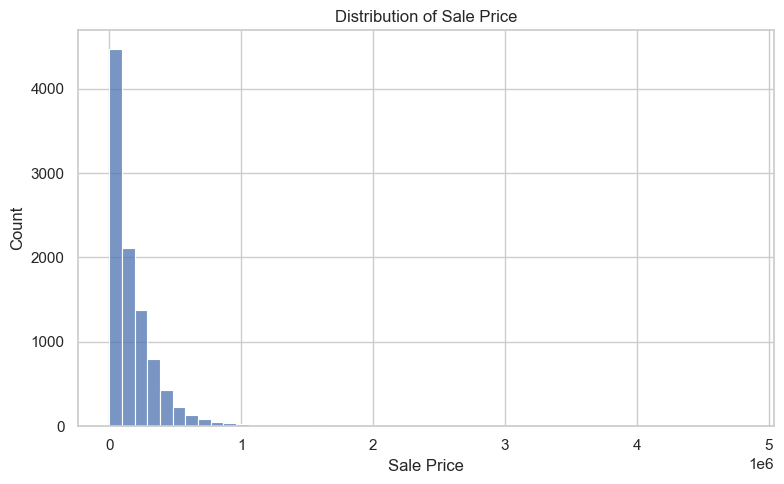

In [26]:
plt.figure(figsize=(8, 5))
sns.histplot(df_model["target_sale_price"], bins=50)
plt.title("Distribution of Sale Price")
plt.xlabel("Sale Price")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### 4.2 Log Transformation of Sale Price

To reduce skewness and stabilize the target distribution, I transform the target using the natural logarithm. This makes the distribution more suitable for model training and interpretation.

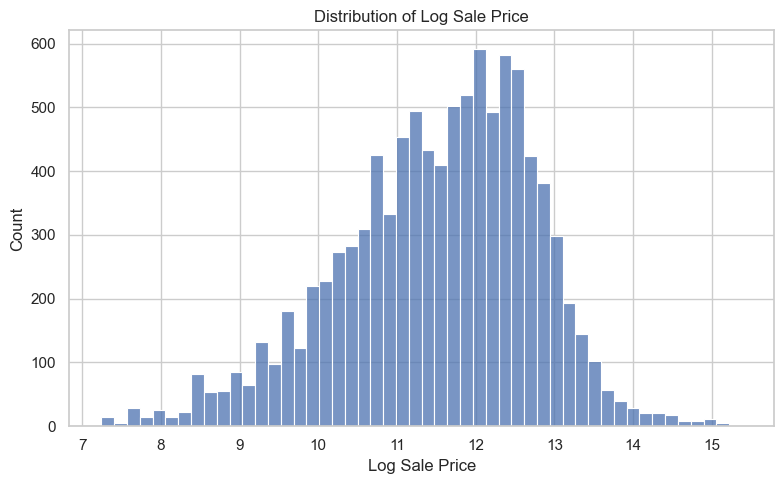

In [27]:
df_model["log_sale_price"] = np.log(df_model["target_sale_price"])

plt.figure(figsize=(8, 5))
sns.histplot(df_model["log_sale_price"], bins=50)
plt.title("Distribution of Log Sale Price")
plt.xlabel("Log Sale Price")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## V. Exploratory Data Analysis

### 5.1 Temporal Pattern: Sale Date

Because `sale_price` reflects market value at the time of transaction, `sale_date` is an important contextual variable. To examine the time pattern, I extract `sale_year` from `sale_date` and compare log sale price across years.

In [50]:
df_model["sale_date"] = pd.to_datetime(df_model["sale_date"], utc=True, errors="coerce")
df_model["sale_year"] = df_model["sale_date"].dt.year

df_model[["sale_date", "sale_year"]].head()

,sale_date,sale_year
0,2015-02-18 05:00:00+00:00,2015
1,2021-11-15 05:00:00+00:00,2021
2,2025-05-01 04:00:00+00:00,2025
3,2022-10-26 04:00:00+00:00,2022
4,2023-05-01 04:00:00+00:00,2023


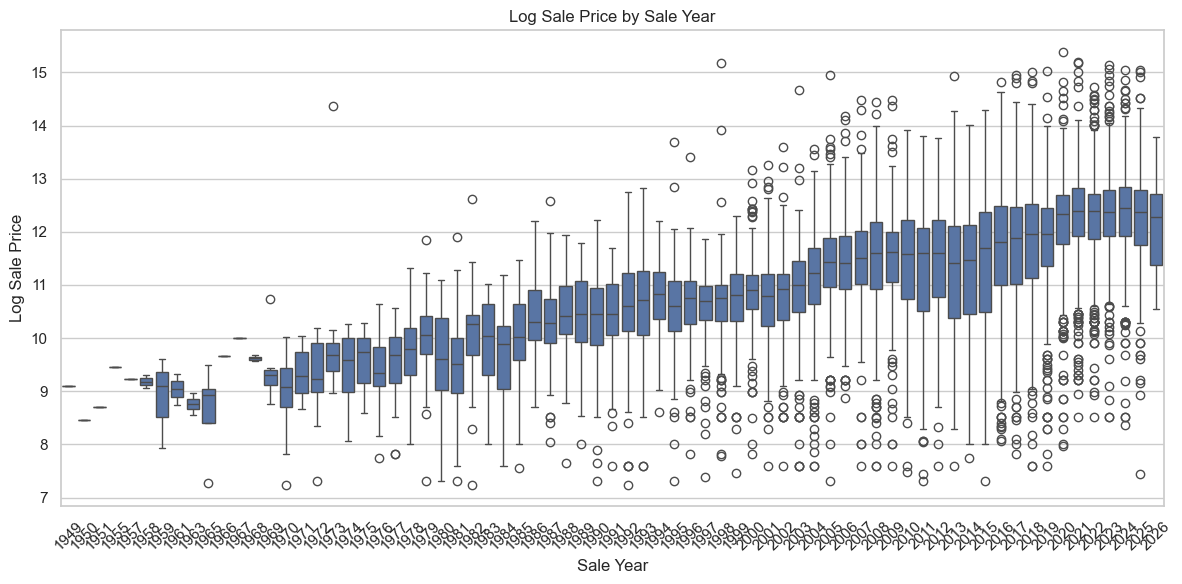

In [51]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_model, x="sale_year", y="log_sale_price")
plt.xticks(rotation=45)
plt.title("Log Sale Price by Sale Year")
plt.xlabel("Sale Year")
plt.ylabel("Log Sale Price")
plt.tight_layout()
plt.show()

The plot suggests a clear temporal pattern: more recent transactions tend to have higher observed log sale prices than older transactions. This likely reflects broader market changes over time, including inflation and housing market appreciation, rather than differences in property characteristics alone.

For that reason, `sale_date` is useful to consider during exploratory analysis and feature engineering. However, it is better understood as a contextual market-timing variable than as a core property characteristic, so it is not necessarily included in the final baseline model.

### 5.2 Strong Predictors

#### Total Livable Area vs Log sale price

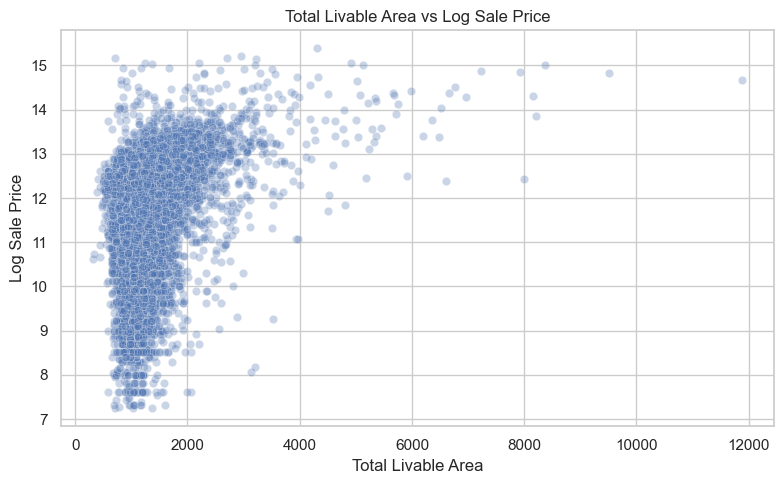

In [36]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_model, x="total_livable_area", y="log_sale_price", alpha=0.3)
plt.title("Total Livable Area vs Log Sale Price")
plt.xlabel("Total Livable Area")
plt.ylabel("Log Sale Price")
plt.tight_layout()
plt.show()

The relationship is positive but not perfectly linear, and there is greater variability in prices among smaller properties.

#### Taxable Building vs Log Sale Price

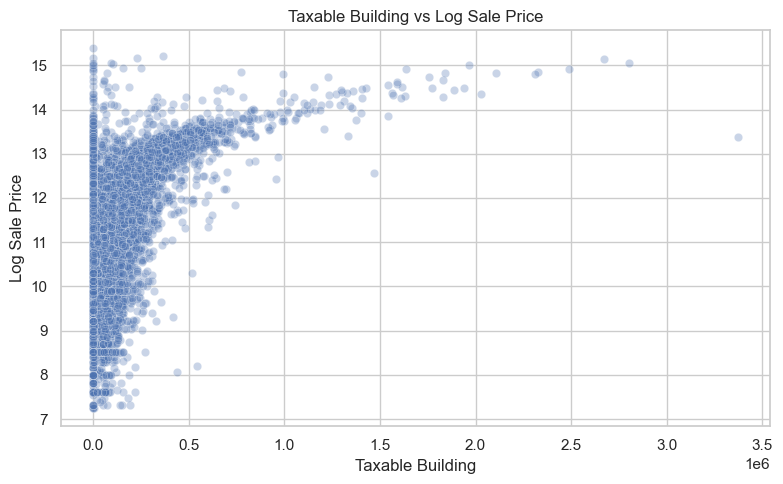

In [37]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_model, x="taxable_building", y="log_sale_price", alpha=0.3)
plt.title("Taxable Building vs Log Sale Price")
plt.xlabel("Taxable Building")
plt.ylabel("Log Sale Price")
plt.tight_layout()
plt.show()

Taxable building value reflects the government’s assessment of the building’s worth and is used for property taxation. As expected, it shows a strong relationship with sale price.

#### Taxable Land vs Log Sale Price

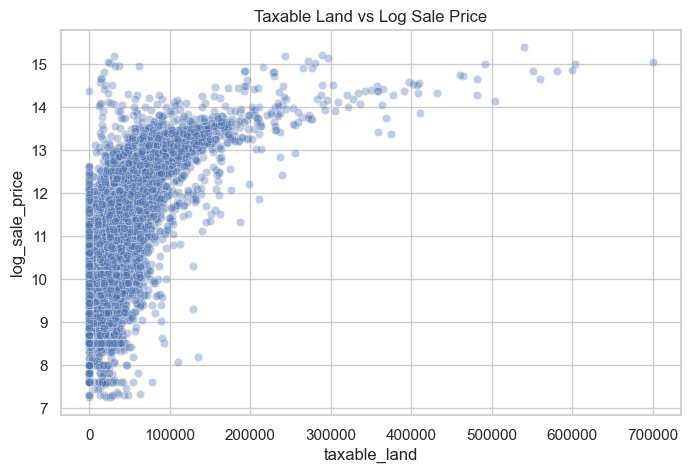

In [38]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df_model,
    x="taxable_land",
    y="log_sale_price",
    alpha=0.35
)

plt.title("Taxable Land vs Log Sale Price")
plt.show()

Taxable land value shows a positive relationship with sale price, although the relationship is weaker than that of taxable building value.

#### Quality Grade vs Log Sale Price

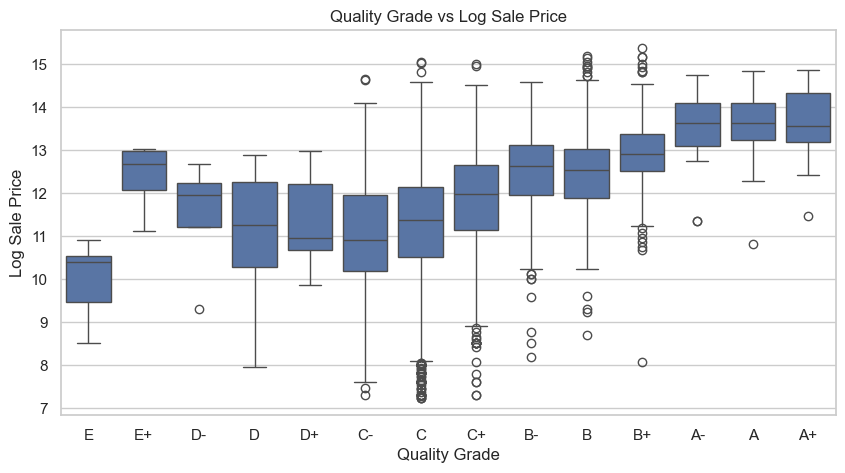

In [41]:

grade_order = [
    "E", "E+",
    "D-", "D", "D+",
    "C-", "C", "C+",
    "B-", "B", "B+",
    "A-", "A", "A+"
]

plt.figure(figsize=(10,5))

sns.boxplot(
    data=df_model,
    x="quality_grade",
    y="log_sale_price",
    order=grade_order
)

plt.xlabel("Quality Grade")
plt.ylabel("Log Sale Price")
plt.title("Quality Grade vs Log Sale Price")

plt.show()

Quality grade shows a clear and strong positive relationship with sale price.

### 5.3 Moderate predictors

#### Taxable Land vs Log Sale Price

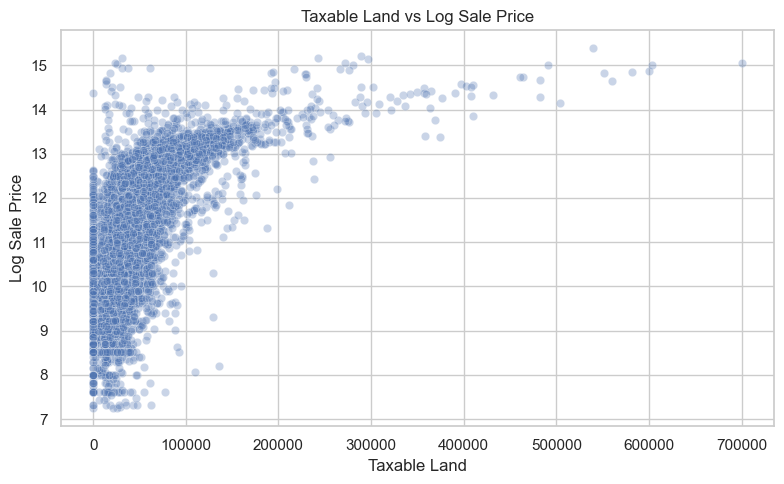

In [43]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_model, x="taxable_land", y="log_sale_price", alpha=0.3)
plt.title("Taxable Land vs Log Sale Price")
plt.xlabel("Taxable Land")
plt.ylabel("Log Sale Price")
plt.tight_layout()
plt.show()

`taxable_land` appears to be moderately useful. It is positively associated with sale price, but the relationship is weaker and noisier than the one observed for `taxable_building`.

#### Interior Condition vs Log Sale Price

Note that the coding direction of the condition variables appears to be reversed: lower numeric values correspond to better condition, while higher values correspond to worse condition. This explains why higher condition scores are associated with lower sale prices in the plots. For the final interpretable baseline model, it would be preferable to reverse these variables so that larger values consistently represent better property condition.

In [56]:
df_model["interior_condition_rev"] = 8 - df_model["interior_condition"]
df_model["exterior_condition_rev"] = 8 - df_model["exterior_condition"]

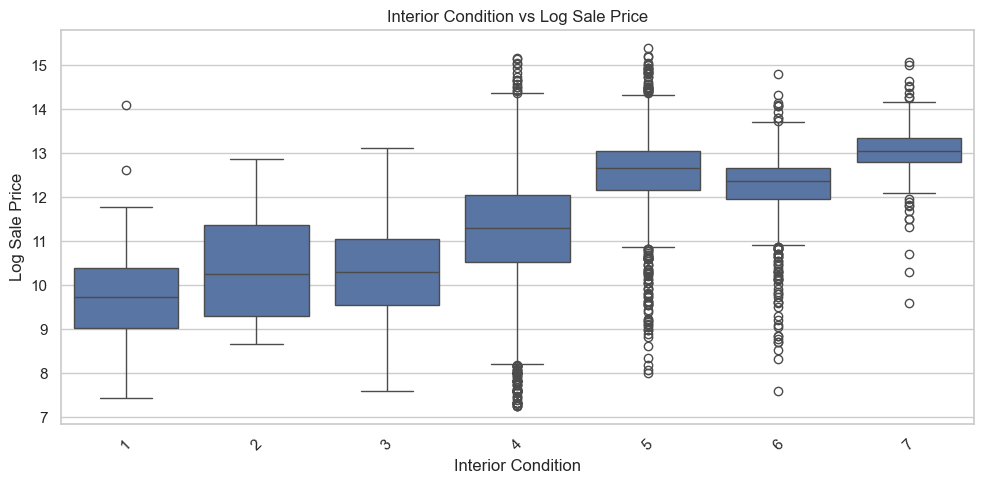

In [57]:


plt.figure(figsize=(10, 5))
sns.boxplot(data=df_model, x="interior_condition_rev", y="log_sale_price")
plt.xticks(rotation=45)
plt.title("Interior Condition vs Log Sale Price")
plt.xlabel("Interior Condition")
plt.ylabel("Log Sale Price")
plt.tight_layout()
plt.show()

`interior_condition` appears to have moderate predictive value. Better interior condition tends to be associated with higher prices, although there is still substantial overlap across categories.

#### Exterior Condition vs Log Sale Price

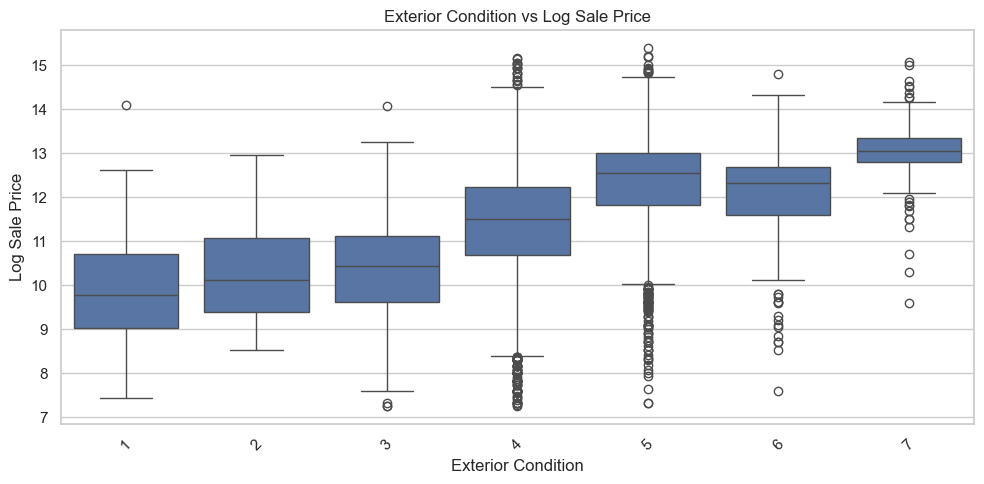

In [55]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_model, x="exterior_condition_rev", y="log_sale_price")
plt.xticks(rotation=45)
plt.title("Exterior Condition vs Log Sale Price")
plt.xlabel("Exterior Condition")
plt.ylabel("Log Sale Price")
plt.tight_layout()
plt.show()

`exterior_condition` also appears to be meaningfully related to log sale price. Its overall pattern is similar to `interior_condition`, suggesting that exterior condition may also provide useful information for the model, even if the relationship is somewhat less clear than the one observed for `quality_grade`.

### 5.4 Weak predictors

#### Bedrooms vs Log Sale Price

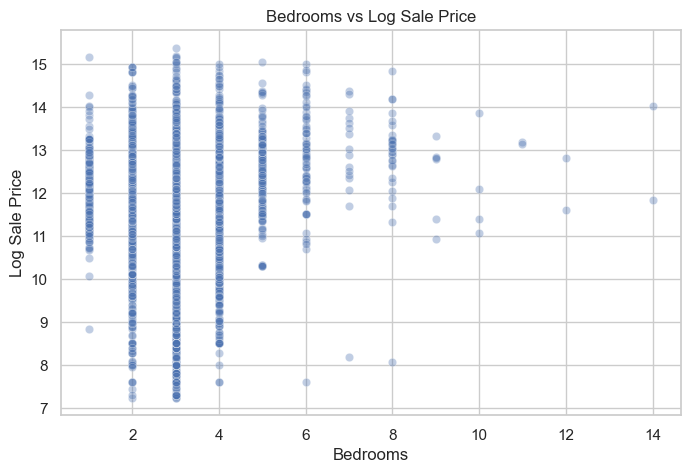

In [47]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df_model,
    x="bedrooms",
    y="log_sale_price",
    alpha=0.35
)

plt.xlabel("Bedrooms")
plt.ylabel("Log Sale Price")
plt.title("Bedrooms vs Log Sale Price")

plt.show()

`bedrooms` does not appear to be a strong standalone predictor. Properties with the same number of bedrooms still show a wide range of observed sale prices.

#### Bathrooms vs Log Sale Price

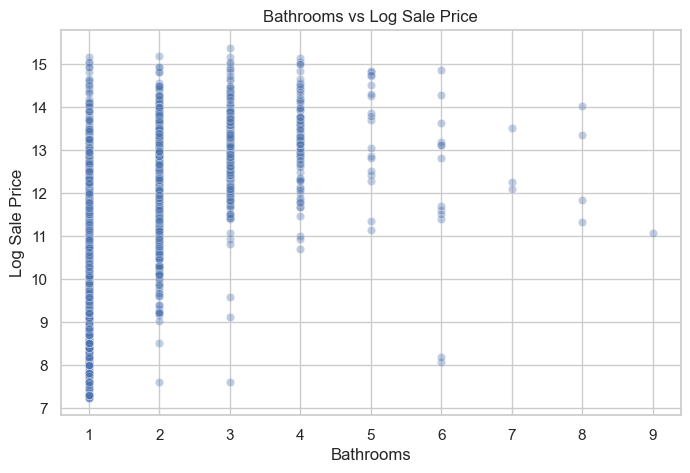

In [48]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df_model,
    x="bathrooms",
    y="log_sale_price",
    alpha=0.35
)

plt.xlabel("Bathrooms")
plt.ylabel("Log Sale Price")
plt.title("Bathrooms vs Log Sale Price")

plt.show()

Bathrooms show a weak-to-moderate positive relationship with sale price, but there is still substantial variation within each bathroom category.

#### Garage Spaces vs Log Sale Price

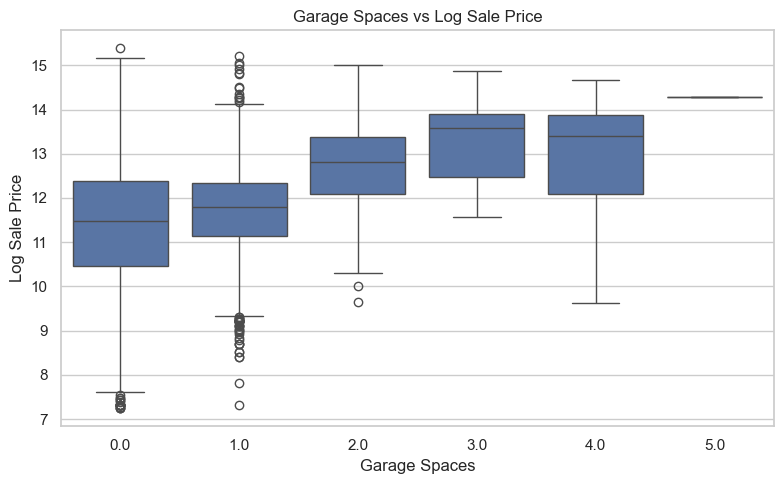

In [60]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_model, x="garage_spaces", y="log_sale_price")
plt.title("Garage Spaces vs Log Sale Price")
plt.xlabel("Garage Spaces")
plt.ylabel("Log Sale Price")
plt.tight_layout()
plt.show()

### 5.5 Low-value predictors
#### Age vs Log Sale Price

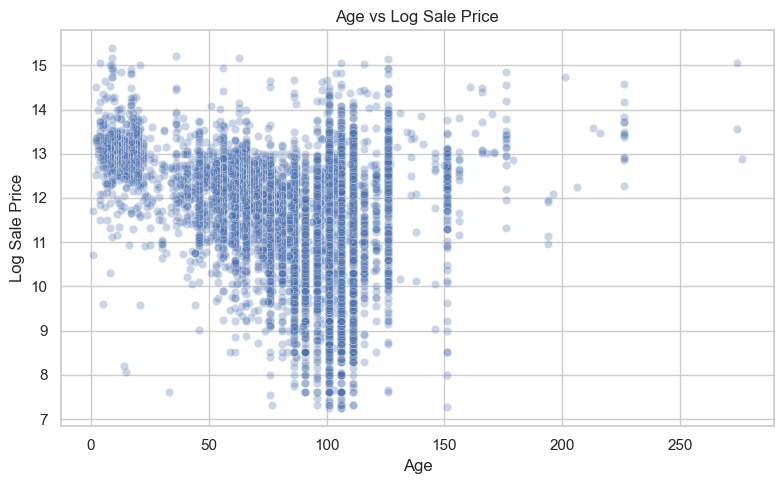

In [49]:
df_model["age"] = df_model["assessment_year"] - df_model["year_built"]

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_model, x="age", y="log_sale_price", alpha=0.3)
plt.title("Age vs Log Sale Price")
plt.xlabel("Age")
plt.ylabel("Log Sale Price")
plt.tight_layout()
plt.show()

`age` does not appear to provide a strong standalone relationship with log sale price. The observed pattern is weak and does not show a clear trend, so age is likely less informative than size, assessment, or quality variables.

## VI. Feature Engineering Outline

Based on the exploratory analysis, several feature engineering steps are necessary before model training.

### 6.1 Log Transformation of the Target

The raw `target_sale_price` distribution is heavily right-skewed. To make the target more stable and easier to model, the training target should be transformed as:

`log_sale_price = log(target_sale_price)`

This transformation reduces skewness, limits the influence of extreme values, and makes model fitting more reliable.

### 6.2 Derived Age Feature

A property age feature can be created from the assessment year and year built:

`age = assessment_year - year_built`

Although age did not appear to be a strong standalone predictor in the EDA, it may still contribute useful information when combined with other structural and quality-related variables.

### 6.3 Encoding Categorical Variables

Several useful predictors are categorical rather than numeric, including:

- `quality_grade`
- `interior_condition`
- `exterior_condition`

These variables need to be encoded before model training. For linear models, one-hot encoding is appropriate. For tree-based models, simpler categorical handling approaches may also be sufficient depending on the implementation.

### 6.4 Rare Category Handling

Some categorical levels may appear only a small number of times in the dataset. These rare categories can make the model less stable and may introduce noise. To reduce sparsity, infrequent levels should be grouped into a shared category such as `"Other"` before encoding.

### 6.5 Temporal Features from Sale Date

The EDA suggests that transaction timing matters: more recent transactions tend to have higher log sale prices than older transactions. This likely reflects broader market changes over time, including inflation and housing market appreciation, rather than differences in property characteristics alone.

Because of this, `sale_date` is useful to examine during exploratory analysis and may be incorporated in future model extensions through a derived feature such as `sale_year` or `years_since_sale`. However, it is not treated here as a required core feature for the main interpretable baseline model.

### 6.6 Exclusion of Likely Bundle Sales

Likely bundle sales should be excluded before final model training. These records can be identified when multiple properties share the exact same `sale_date` and `target_sale_price`, suggesting that the price refers to a combined transaction rather than a single property.

In this notebook, likely bundle sales were flagged and a filtered modeling dataset was created by excluding observations with `is_likely_bundle = True`.

## VII. Recommended Features for Modeling

Based on the exploratory data analysis, the recommended features for modeling are selected according to three criteria: their observed relationship with sale price, their interpretability, and their suitability for an interpretable baseline model.

### Core Features

The following variables are the strongest candidates for the main OLS specification:

- **total_livable_area**
  - Shows a clear positive relationship with sale price
  - Directly reflects usable living space
  - One of the most important structural predictors in the dataset

- **taxable_building**
  - Shows the strongest observed relationship with sale price
  - Represents the assessed value of the building
  - Likely to be highly predictive, but should be used cautiously because it may be close to the target conceptually

- **taxable_land**
  - Positively associated with sale price
  - Captures part of land value and location-related effects
  - Less powerful than `taxable_building`, but still useful

- **quality_grade**
  - Shows a strong and fairly consistent relationship with sale price
  - Captures overall construction quality and condition
  - A key categorical feature for the baseline model

- **interior_condition**
  - Appears meaningfully related to sale price
  - Reflects internal livability and maintenance quality
  - More useful than exterior condition in the EDA

### Secondary or Optional Features

The following variables are not the strongest standalone predictors, but they may still be worth testing as supplementary controls:

- **exterior_condition**
  - Shows some relationship with price, although weaker than `interior_condition`
  - May provide incremental information when combined with stronger quality variables

- **bedrooms**
  - Weak as a standalone predictor
  - Still potentially useful as a control variable when included alongside size and quality features

- **bathrooms**
  - Also weaker than the main predictors
  - May still contribute explanatory value in a multivariable model

### Deprioritized Features

The following variables were examined but are not prioritized for the main baseline specification:

- **age**
  - Created as `age = assessment_year - year_built`
  - More interpretable than raw `year_built`
  - However, it showed only a weak and inconsistent relationship with sale price in the EDA

- **sale_date / temporal features**
  - Transaction timing appears to matter in the exploratory analysis
  - However, this variable is better understood as a contextual market factor rather than a core property characteristic
  - It may be explored later as an extension, but it is not treated here as a required feature for the main interpretable baseline model

### Excluded or Not Recommended for Initial Modeling

The following variables are not recommended for the initial model:

- **year_built (raw form)**
  - Less interpretable than derived age, and not clearly useful on its own

- **parcel_number**
  - Identifier only, with no predictive meaning

- **raw location strings**
  - Potentially useful only after additional processing or geospatial encoding

- **rare or inconsistent categorical values**
  - Should be cleaned, grouped, or encoded before use

### Summary

Overall, the most useful feature groups in this dataset are:

- **Size-related features**: `total_livable_area`
- **Assessment-related features**: `taxable_building`, `taxable_land`
- **Quality-related features**: `quality_grade`, `interior_condition`, `exterior_condition`

These variables provide the strongest foundation for an interpretable baseline model of property sale price. Among them, `taxable_building` appears especially predictive, though it should be used cautiously because it is conceptually close to the target. Secondary variables such as `bedrooms` and `bathrooms` may still be worth testing as supplementary controls, but they are not treated as the primary drivers of price in the final recommendation.

## VIII. Model Recommendations

Based on the exploratory data analysis, a **tree-based regression model** is recommended as the primary candidate model for this stage of the project. However, the final model choice should be determined through model comparison rather than EDA alone.

### Primary Candidate Model: Tree-Based Regression Model

The primary candidate model is a tree-based regression model using log-transformed sale price as the target variable.

- **Target variable**
  - `log_sale_price`

### Why a Tree-Based Model is a Strong Candidate

The EDA suggests that property sale price may not be explained by purely linear relationships. Several important predictors, such as structural size, assessed value, property quality, and condition, may interact with each other in ways that are difficult to capture with a simple linear specification.

A tree-based model is therefore a strong candidate because it can capture:

- nonlinear relationships between predictors and sale price
- interaction effects among property characteristics
- threshold effects, such as price changes after certain levels of livable area or assessed value
- mixed feature patterns across size, quality, condition, and time-related variables

For this reason, a tree-based model is expected to be a good fit for the housing price prediction task.

### Model Comparison Strategy

Although the tree-based model is the preferred candidate based on the structure of the problem, the final model should be selected through empirical testing.

In the modeling stage, we will compare multiple model types, including:

- OLS regression
- tree-based regression models

OLS regression remains useful as a transparent baseline because it provides interpretable coefficients and helps show the general direction of relationships between variables and sale price.

Tree-based models, on the other hand, are useful because they can model nonlinear patterns and interactions more flexibly.

The final model should be selected based on validation or test-set performance metrics, such as:

- R²
- RMSE
- MAE

This ensures that the final recommendation is based on actual predictive performance rather than only on assumptions from exploratory analysis.

### Recommended Model Features

The candidate models should prioritize the following variables:

- `total_livable_area`
- `taxable_building`
- `taxable_land`
- `quality_grade`
- `interior_condition`
- `exterior_condition`
- `garage_spaces`
- `assessment_year`
- `year_built_int`

These variables capture major dimensions of property value, including size, assessed value, quality, condition, and time-related effects.

Additional variables can also be tested as secondary predictors:

- `bedrooms`
- `bathrooms`
- `sale_year` or `years_since_sale`

These may provide additional predictive value, especially in tree-based models that can capture interaction effects.

### Important Limitation: Potential Leakage

The variable **taxable_building** should be used with caution. Because it represents an assessed building value, it is conceptually close to the target variable and may introduce a form of target proximity.

For that reason, we recommend testing model specifications both:

- **with `taxable_building`**
- **without `taxable_building`**

This helps evaluate whether the model is overly dependent on assessment-related variables, or whether structural and quality-related features can still support reliable prediction.

### Final Recommendation

The recommended approach is to treat the **tree-based regression model as the primary candidate model**, while also testing OLS regression as an interpretable baseline.

The final model should be selected after comparing model performance on validation or test data. If the tree-based model achieves stronger predictive metrics, it should be selected as the final model. This approach keeps the recommendation grounded in the EDA while leaving the final decision to empirical model evaluation.